# nb06 — ATAC support for reproducible RNA programs

## Scientific question
For the provisional RNA programs recovered in both captures, is related gene-level
chromatin accessibility elevated in the same population, and do RNA and ATAC module
scores covary **within genuinely paired Multiome cells**?

## Analysis strategy
Load nb04's cached Multiome RNA and nb05's shortlist. Read corresponding
`obsm['ATAC_gene_activity']` rows by **cell ID**, with gene names from
`uns['ATAC_gene_activity_var_names']`. Audit coverage, score the same covered genes
in both layers, and compare within-type, site-specific and depth-adjusted
associations. Inspect shared RNA leading-edge genes and relative population states.

The five programs below are provisional choices from the reviewed donor-15078 run.
The donor itself is read from nb04, not hard-coded. Changing the donor may require
changing this list to supported programs from its own nb05 run.

**No CITE–Multiome cells are paired.** CITE provides population-level RNA replication
only. No peak-to-gene inference, protein analysis, pseudobulk or latent integration
is performed here. Existing notebooks and RNA results are left intact.

In [1]:
from pathlib import Path
import sys
import subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Same Drive root as nb01. No changes to the original benchmark files.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'anndata>=0.11,<0.13'])
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE_PATH = Path.cwd().resolve()
    if not (BASE_PATH / 'src').is_dir():
        BASE_PATH = BASE_PATH.parent

if not (BASE_PATH / 'src/single_donor_workflow.py').is_file():
    raise FileNotFoundError('Copy the updated src/, configs/ and new notebooks to the project on Drive first.')
sys.path.insert(0, str(BASE_PATH))
import pandas as pd
from IPython.display import display, Image
from configs.paths import CITE_H5AD, MULTIOME_H5AD
from src.single_donor_io import output_dirs

OUTPUT_ROOT = BASE_PATH / 'results/single_donor'
DIRS = output_dirs(OUTPUT_ROOT)
print('Colab:', IN_COLAB, '| Project:', BASE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True | Project: /content/drive/MyDrive/multiomics-relationship-modeling


## Inputs and provisional program panel
Copy `src/atac_programs.py`, `src/atac_plots.py`, and this notebook to your existing
Drive project. Existing shared modules must be the updated versions used for nb04/05.
Restart a reused Colab runtime after copying Python modules.

The loader checks nb04 artifact hashes, nb05 completion and whether each requested
program still has positive supported RNA in both captures and positive direction in
nb05's balanced draw. It checks shortlist NES/q-values against nb04's source tables.
The shortlist is not proof of replication across people or robustness to site.

In [2]:
from src.atac_programs import load_inputs, run_atac, INITIAL_PROGRAMS

PROGRAMS = list(INITIAL_PROGRAMS)
MIN_MODULE_GENES = 10
MIN_ORIGINAL_SET_COVERAGE = 0.20
MIN_CELLS_FOR_ASSOCIATION = 50
RELATIVE_STATE_THRESHOLD = 0.50
RANDOM_SEED = 42

manifest, selected, rna_cache, rna_obs, rna_genes, universe = load_inputs(OUTPUT_ROOT, PROGRAMS)
print('Selected donor:', manifest['donor'])
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(selected[['cell_type', 'pathway', 'NES_cite', 'NES_multiome',
                      'q_value_cite', 'q_value_multiome', 'shared_leading_edge']])
display(rna_obs.groupby(['cell_type_harmonized', 'Site'], observed=True).size().rename('n_cells').reset_index())
del rna_cache, rna_obs, rna_genes

Selected donor: 15078


,cell_type,pathway,NES_cite,NES_multiome,q_value_cite,q_value_multiome,shared_leading_edge
0,CD14 monocytes,Inflammatory Response,1.886618,1.868768,0.010355,0.012084,AHR;AQP9;ATP2B1;C5AR1;CD14;CD55;CSF3R;CXCL8;CYBB;EREG;FPR1;GNAI3;HBEGF;HIF1A;IFNGR2;IL10RA;IL1B;IRF1;KIF1B;KLF6;LYN;MEFV;MXD1;NAMPT;NFKBIA;NLRP3;NOD2;P2RX7;PLAUR;PROK2;PSEN1;PTAFR;PTGER4;PTPRE;RAF1;RNF144B;SGMS2;SLC31A2;STAB1;TLR1;TLR2;TNFRSF1B
1,CD14 monocytes,TNF-alpha Signaling via NF-kB,2.042902,1.954407,0.010355,0.012084,ATF3;ATP2B1;B4GALT5;BCL2A1;BCL6;CCNL1;CD44;CD83;CEBPB;CEBPD;CFLAR;DENND5A;DUSP1;EGR1;ETS2;FOS;FOSB;FOSL2;HBEGF;IER3;IFNGR2;IL1B;IL6ST;IRF1;IRS2;JUN;KDM6B;KLF10;KLF4;KLF6;KYNU;LDLR;MARCKS;MCL1;MXD1;NAMPT;NFE2L2;NFIL3;NFKBIA;NR4A2;PDLIM5;PER1;PLAUR;PLEK;PNRC1;PTGER4;PTGS2;PTPRE;REL;RHOB;SAT1;SERPINB2;SGK1;SLC16A6;SLC2A3;SOCS3;SOD2;TANK;TLR2;TNFAIP2;TNFAIP3;TRIB1;ZFP36
2,CD16 monocytes,Interferon Alpha Response,1.947899,1.954336,0.008788,0.009088,B2M;BST2;CASP1;CD74;EPSTI1;GBP2;GBP4;HLA-C;IFI30;IFI44L;IFIT2;IFIT3;IFITM2;IL15;IRF1;ISG15;LAP3;LPAR6;LY6E;MX1;NUB1;OAS1;OGFR;PARP12;PARP14;PARP9;PLSCR1;PSMB9;PSME2;SAMD9L;SP110;STAT2;TENT5A;TRIM14;TXNIP
3,Lymphoid progenitors,E2F Targets,1.803852,1.909167,0.009829,0.012861,ANP32E;ASF1B;ATAD2;AURKB;BARD1;BIRC5;CBX5;CCNB2;CCP110;CDC20;CDC25B;CDCA8;CDK1;CDK4;CDKN2A;CHEK1;CIT;CKS2;CTCF;CTPS1;DCK;DEK;DIAPH3;DONSON;DUT;EZH2;GINS4;HELLS;HMGA1;HMGB2;HMGB3;HNRNPD;KIF2C;LMNB1;LUC7L3;MAD2L1;MCM3;MCM4;MCM6;MCM7;MELK;MKI67;MMS22L;MSH2;MXD3;MYBL2;NAA38;NAP1L1;NASP;NOP56;NUDT21;PCNA;PDS5B;PHF5A;PNN;PRKDC;PSIP1;RACGAP1;RAD21;RAD51AP1;RAN;RANBP1;RBBP7;RFC3;RPA3;RRM2;SLBP;SMC1A;SMC3;SMC4;SMC6;SNRPB;SPC24;SPC25;SRSF1;STAG1;STMN1;SYNCRIP;TACC3;TCF19;TMPO;TOP2A;TRA2B;TUBB;USP1;XPO1
4,MK/E progenitors,Myc Targets V1,2.065594,2.036687,0.008886,0.012462,ABCE1;APEX1;C1QBP;CANX;CBX3;CCT2;CCT3;CCT4;CCT5;CCT7;CDK4;CLNS1A;COPS5;COX5A;CYC1;DDX18;DDX21;DEK;DUT;EEF1B2;EIF1AX;EIF2S2;EIF3B;EIF3J;EIF4A1;EIF4H;FBL;G3BP1;GNL3;GSPT1;HDAC2;HDGF;HNRNPA1;HNRNPA2B1;HNRNPA3;HNRNPC;HNRNPD;HNRNPR;HNRNPU;HPRT1;HSP90AB1;HSPD1;HSPE1;ILF2;IMPDH2;KPNB1;LDHA;LSM7;MCM4;MCM5;MCM6;MCM7;MYC;NHP2;NME1;NOLC1;NOP56;NPM1;PA2G4;PABPC4;PCNA;PHB;PHB2;POLD2;PPIA;PPM1G;PRDX3;PRDX4;PSMA1;PSMA2;PSMA4;PSMA7;PSMD1;PTGES3;RACK1;RAD23B;RAN;RPL14;RPL18;RPL22;RPL34;RPL6;RPLP0;RPS10;RPS2;RPS3;RPS5;RPS6;RRM1;RSL1D1;RUVBL2;SERBP1;SET;SF3B3;SLC25A3;SMARCC1;SNRPA1;SNRPD1;SRPK1;SRSF2;SRSF3;SSB;SSBP1;SYNCRIP;TCP1;TRIM28;TUFM;TXNL4A;TYMS;UBA2;VDAC1;VDAC3;XPO1;XRCC6;YWHAE


,cell_type_harmonized,Site,n_cells
0,B cells,site1,670
1,B cells,site2,387
2,B cells,site4,1741
3,CD14 monocytes,site1,921
4,CD14 monocytes,site2,1308
5,CD14 monocytes,site4,1014
6,CD16 monocytes,site1,66
7,CD16 monocytes,site2,209
8,CD16 monocytes,site4,251
9,CD4 T cells,site1,1379


## Representation, scoring and safeguards
- **RNA:** retain nb04's independent log1p(CP10k) RNA; do not normalize it again.
- **ATAC:** use gene activity **as stored**. nb03 recorded nonnegative processed
  scores (maximum about 7 in its inspected overlap). This does not establish the
  original transformation. Do not pretend these are counts or automatically log
  them again. A log1p sensitivity score is reported separately, not substituted.
- **Coverage:** use the intersection of the GMT pathway, nb04's shared eligible RNA
  universe and available ATAC symbols. Exclude features constant in either layer.
  Both module scores use exactly this same gene list. Require at least 10 genes and
  20% of the original GMT membership; save excluded genes and coverage either way.
  Absent or inadequate coverage is **missing evidence**, never negative support.
- **Reference:** within each layer, calculate per-gene means and variances with equal
  weight for every retained cell type, and equal weight for cells within a type.
  Module score is the mean of these gene z-scores. RNA and ATAC are standardized
  separately. Module scores themselves do not have unit variance and cannot be
  interpreted as equal biological effect sizes across layers or pathways.
- **Cell QC:** exclude zero-total ATAC-activity cells from both layers, audit counts,
  and stop on negative/nonfinite activity, mismatched cell IDs or duplicate symbols.
  No new organizer-QC thresholds are silently applied.
- **Associations:** Pearson/Spearman are effect-size summaries, not donor inference.
  Primary results are within the requested population. Pooled correlations are
  labelled separately because cell-type structure can drive them. Minimum 50 cells
  applies to target and site associations; insufficient groups remain visible.
- **Confound sensitivity:** residual Pearson adjusts both scores for log RNA count
  depth, log ATAC peak-count depth when available, and site indicators. Residual
  Spearman is correlation of the OLS residual ranks, not a formal partial-Spearman
  test. If raw depth metadata is missing, the processed activity total is explicitly
  identified as a fallback proxy. Adjustment is a sensitivity check, not causal proof.

No cell-level p-values are used to promote programs merely because they have many cells.
The two CD14 programs may have overlapping genes and are not independent confirmations.

In [3]:
tables, target_summary, atac_manifest = run_atac(
    OUTPUT_ROOT, MULTIOME_H5AD, requested=PROGRAMS,
    min_genes=MIN_MODULE_GENES, min_coverage=MIN_ORIGINAL_SET_COVERAGE,
    min_cells=MIN_CELLS_FOR_ASSOCIATION, threshold=RELATIVE_STATE_THRESHOLD,
    seed=RANDOM_SEED)
print('ATAC depth covariate:', atac_manifest['depth_covariate'])
display(pd.read_csv(DIRS['atac'] / 'cell_counts.csv'))
display(tables['coverage'].drop(columns=['used_genes', 'missing_atac_or_rna']))
print('Complete gene coverage and membership are saved under results/single_donor/atac/.')

ATAC depth covariate: ATAC_nCount_peaks


,cell_type,n_rna_reference,n_atac_usable
0,B cells,2798,2798
1,CD14 monocytes,3243,3243
2,CD16 monocytes,526,526
3,CD4 T cells,3099,3099
4,CD8 T cells,1653,1653
5,Erythroid populations,2851,2851
6,G/M progenitors,341,341
7,HSC,230,230
8,ILC,120,120
9,Lymphoid progenitors,452,452


,program_id,cell_type,pathway,n_original_genes,n_shared_rna_genes,n_measured_in_both,n_variable_in_both,coverage,n_shared_leading_edge,n_covered_leading_edge,analyzed,reason
0,P01,CD14 monocytes,Inflammatory Response,200,128,126,126,0.630000,42,42,True,adequate coverage
1,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,200,160,159,159,0.795000,63,63,True,adequate coverage
2,P03,CD16 monocytes,Interferon Alpha Response,97,84,84,84,0.865979,35,35,True,adequate coverage
3,P04,Lymphoid progenitors,E2F Targets,200,195,195,195,0.975000,86,86,True,adequate coverage
4,P05,MK/E progenitors,Myc Targets V1,200,196,196,196,0.980000,115,115,True,adequate coverage


Complete gene coverage and membership are saved under results/single_donor/atac/.


## 7A — Within-population RNA–ATAC support
Compare the unadjusted and adjusted associations below. Similar elevated population
means and a positive within-population correlation are different observations; one
does not require the other. A narrow range within a type can weaken correlation even
when its mean activity is elevated. Conversely, pooled association can reflect
population composition rather than within-type coordination.

,program_id,cell_type,pathway,scope,group,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,rna_mean,atac_mean,state,log1p_atac_spearman,leading_edge_spearman,rna_score_vs_rna_depth,atac_score_vs_atac_depth
2,P01,CD14 monocytes,Inflammatory Response,cell_type,CD14 monocytes,3243,True,0.195321,0.198761,0.336784,0.325792,0.295613,0.207125,intermediate / mixed,0.141282,0.235861,0.592371,0.617482
21,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,cell_type,CD14 monocytes,3243,True,0.471505,0.435104,0.477397,0.445516,0.291382,0.157299,intermediate / mixed,0.369888,0.431256,0.555335,0.506412
41,P03,CD16 monocytes,Interferon Alpha Response,cell_type,CD16 monocytes,526,True,0.067146,0.076497,0.117519,0.111281,0.189353,0.046514,intermediate / mixed,0.075932,0.057551,0.671142,0.691215
67,P04,Lymphoid progenitors,E2F Targets,cell_type,Lymphoid progenitors,452,True,0.279346,0.340292,0.048267,0.051060,0.067158,-0.037062,intermediate / mixed,0.357775,0.301139,0.708328,0.707799
87,P05,MK/E progenitors,Myc Targets V1,cell_type,MK/E progenitors,298,True,0.331299,0.376373,0.010419,0.008569,0.290063,-0.032376,intermediate / mixed,0.357959,0.390532,0.773673,0.509250


,program_id,cell_type,pathway,evaluated_cell_type,n_cells,rna_mean,atac_mean,rna_median,atac_median,state
1,P01,CD14 monocytes,Inflammatory Response,CD14 monocytes,3243,0.295613,0.207125,0.292557,0.232879,intermediate / mixed
16,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,CD14 monocytes,3243,0.291382,0.157299,0.251100,0.161552,intermediate / mixed
32,P03,CD16 monocytes,Interferon Alpha Response,CD16 monocytes,526,0.189353,0.046514,0.167090,0.077927,intermediate / mixed
54,P04,Lymphoid progenitors,E2F Targets,Lymphoid progenitors,452,0.067158,-0.037062,-0.052135,-0.001920,intermediate / mixed
70,P05,MK/E progenitors,Myc Targets V1,MK/E progenitors,298,0.290063,-0.032376,0.244504,-0.027029,intermediate / mixed


,program_id,cell_type,pathway,scope,group,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,rna_mean,atac_mean,state,log1p_atac_spearman,leading_edge_spearman,rna_score_vs_rna_depth,atac_score_vs_atac_depth
16,P01,CD14 monocytes,Inflammatory Response,target_by_site,site1,921,True,0.304054,0.360206,0.455259,0.453200,0.426691,0.336506,intermediate / mixed,0.285765,0.400594,0.378766,0.539446
17,P01,CD14 monocytes,Inflammatory Response,target_by_site,site2,1308,True,0.190061,0.221577,0.197419,0.203284,0.323183,0.071267,intermediate / mixed,0.196906,0.210677,0.378257,0.748538
18,P01,CD14 monocytes,Inflammatory Response,target_by_site,site4,1014,True,0.296794,0.320691,0.343701,0.335019,0.140992,0.264860,intermediate / mixed,0.288895,0.329649,0.425943,0.549059
35,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,target_by_site,site1,921,True,0.414199,0.477661,0.586637,0.584838,0.536973,0.374099,intermediate / mixed,0.410997,0.478544,0.365726,0.469263
36,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,target_by_site,site2,1308,True,0.228897,0.282800,0.314935,0.314233,0.264380,0.008110,intermediate / mixed,0.255482,0.269514,0.399529,0.731293
37,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,target_by_site,site4,1014,True,0.423852,0.429813,0.480892,0.467187,0.103148,0.152828,intermediate / mixed,0.390815,0.412496,0.404774,0.468637
54,P03,CD16 monocytes,Interferon Alpha Response,target_by_site,site1,66,True,0.423947,0.403945,0.299500,0.321365,0.355810,0.165436,intermediate / mixed,0.388916,0.216073,0.656953,0.530821
55,P03,CD16 monocytes,Interferon Alpha Response,target_by_site,site2,209,True,0.128376,0.126660,0.124000,0.098176,0.293296,-0.047436,intermediate / mixed,0.124006,0.157470,0.406707,0.741374
56,P03,CD16 monocytes,Interferon Alpha Response,target_by_site,site4,251,True,0.166274,0.208999,0.049320,0.058253,0.059033,0.093473,intermediate / mixed,0.213361,0.144046,0.556270,0.635614
73,P04,Lymphoid progenitors,E2F Targets,target_by_site,site1,52,True,0.532300,0.528558,0.242943,0.236319,0.368279,0.192741,intermediate / mixed,0.594212,0.522667,0.794502,0.696918


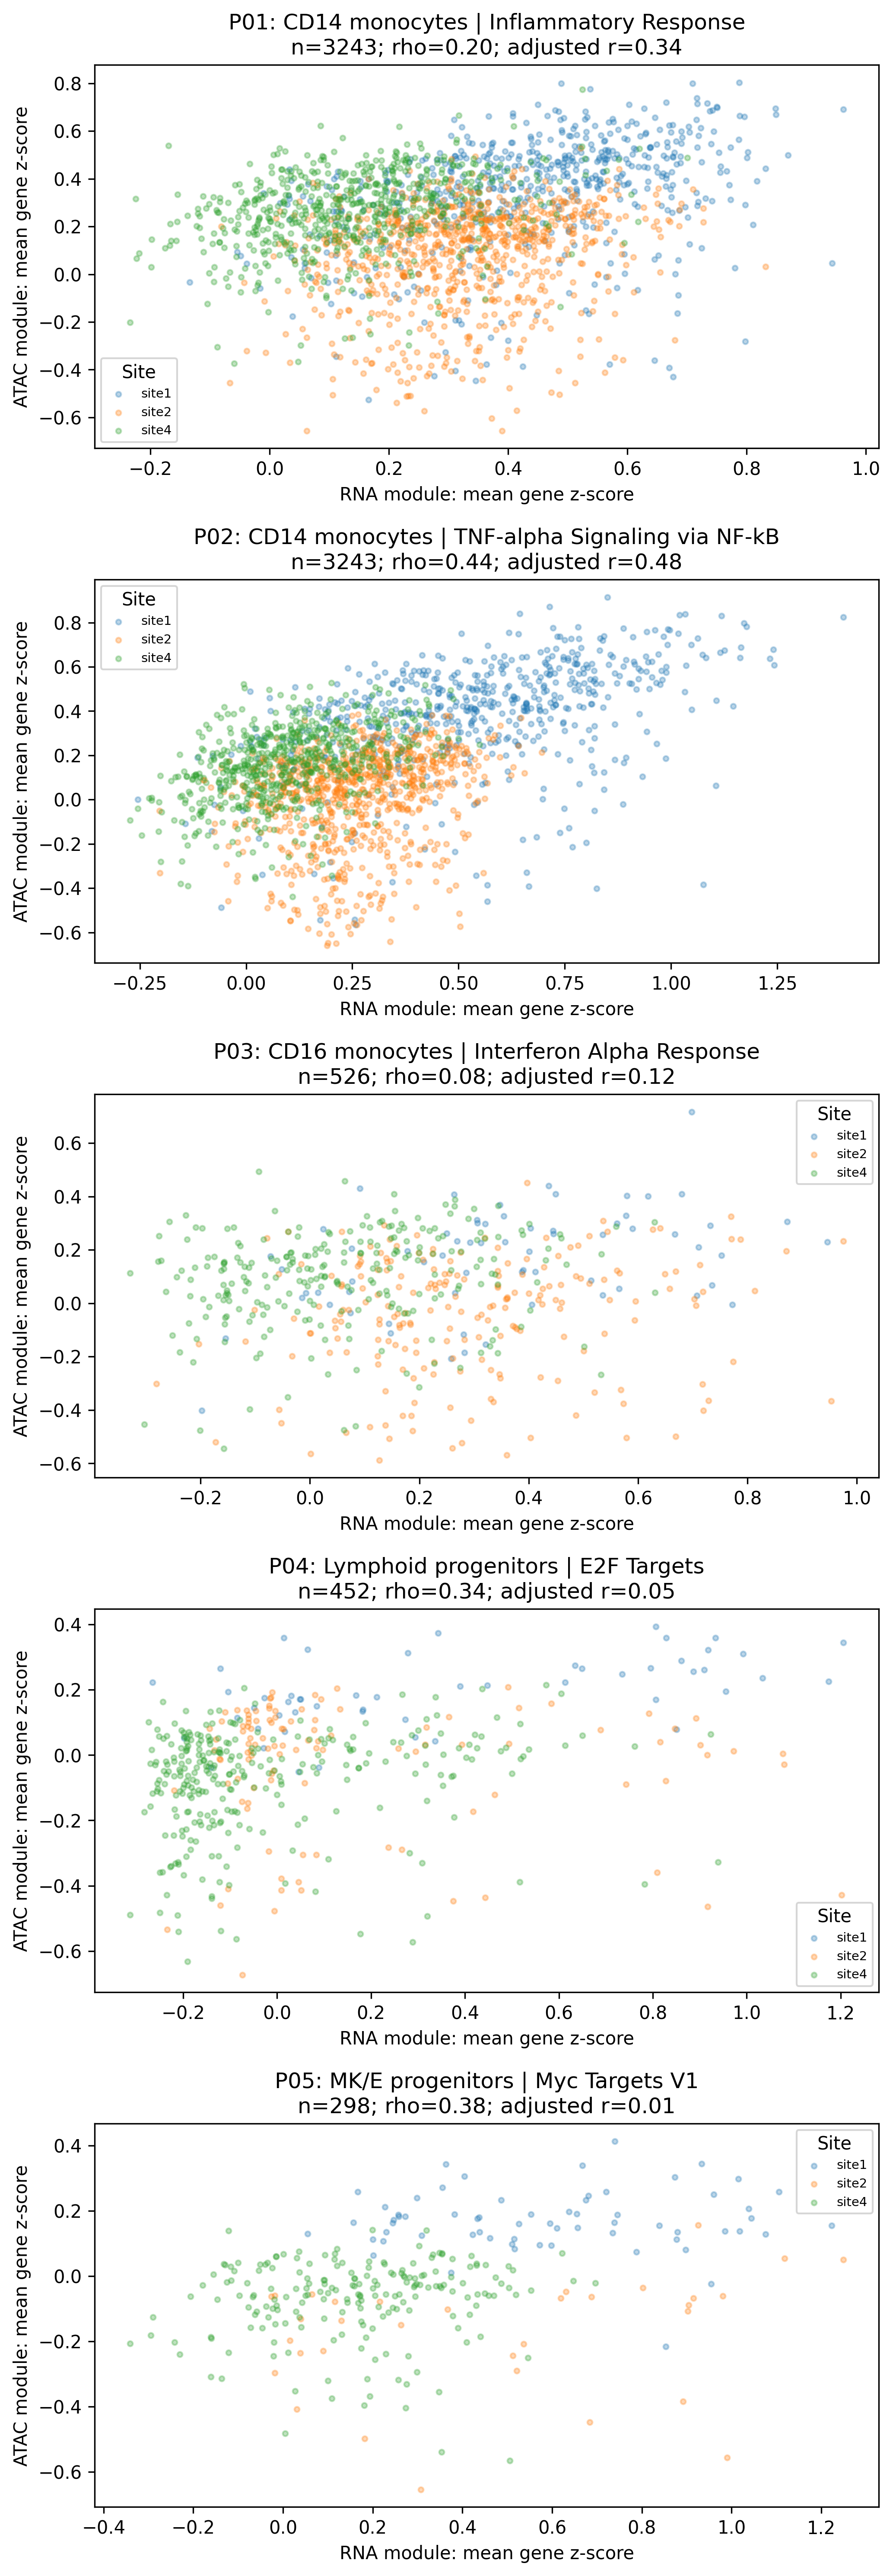

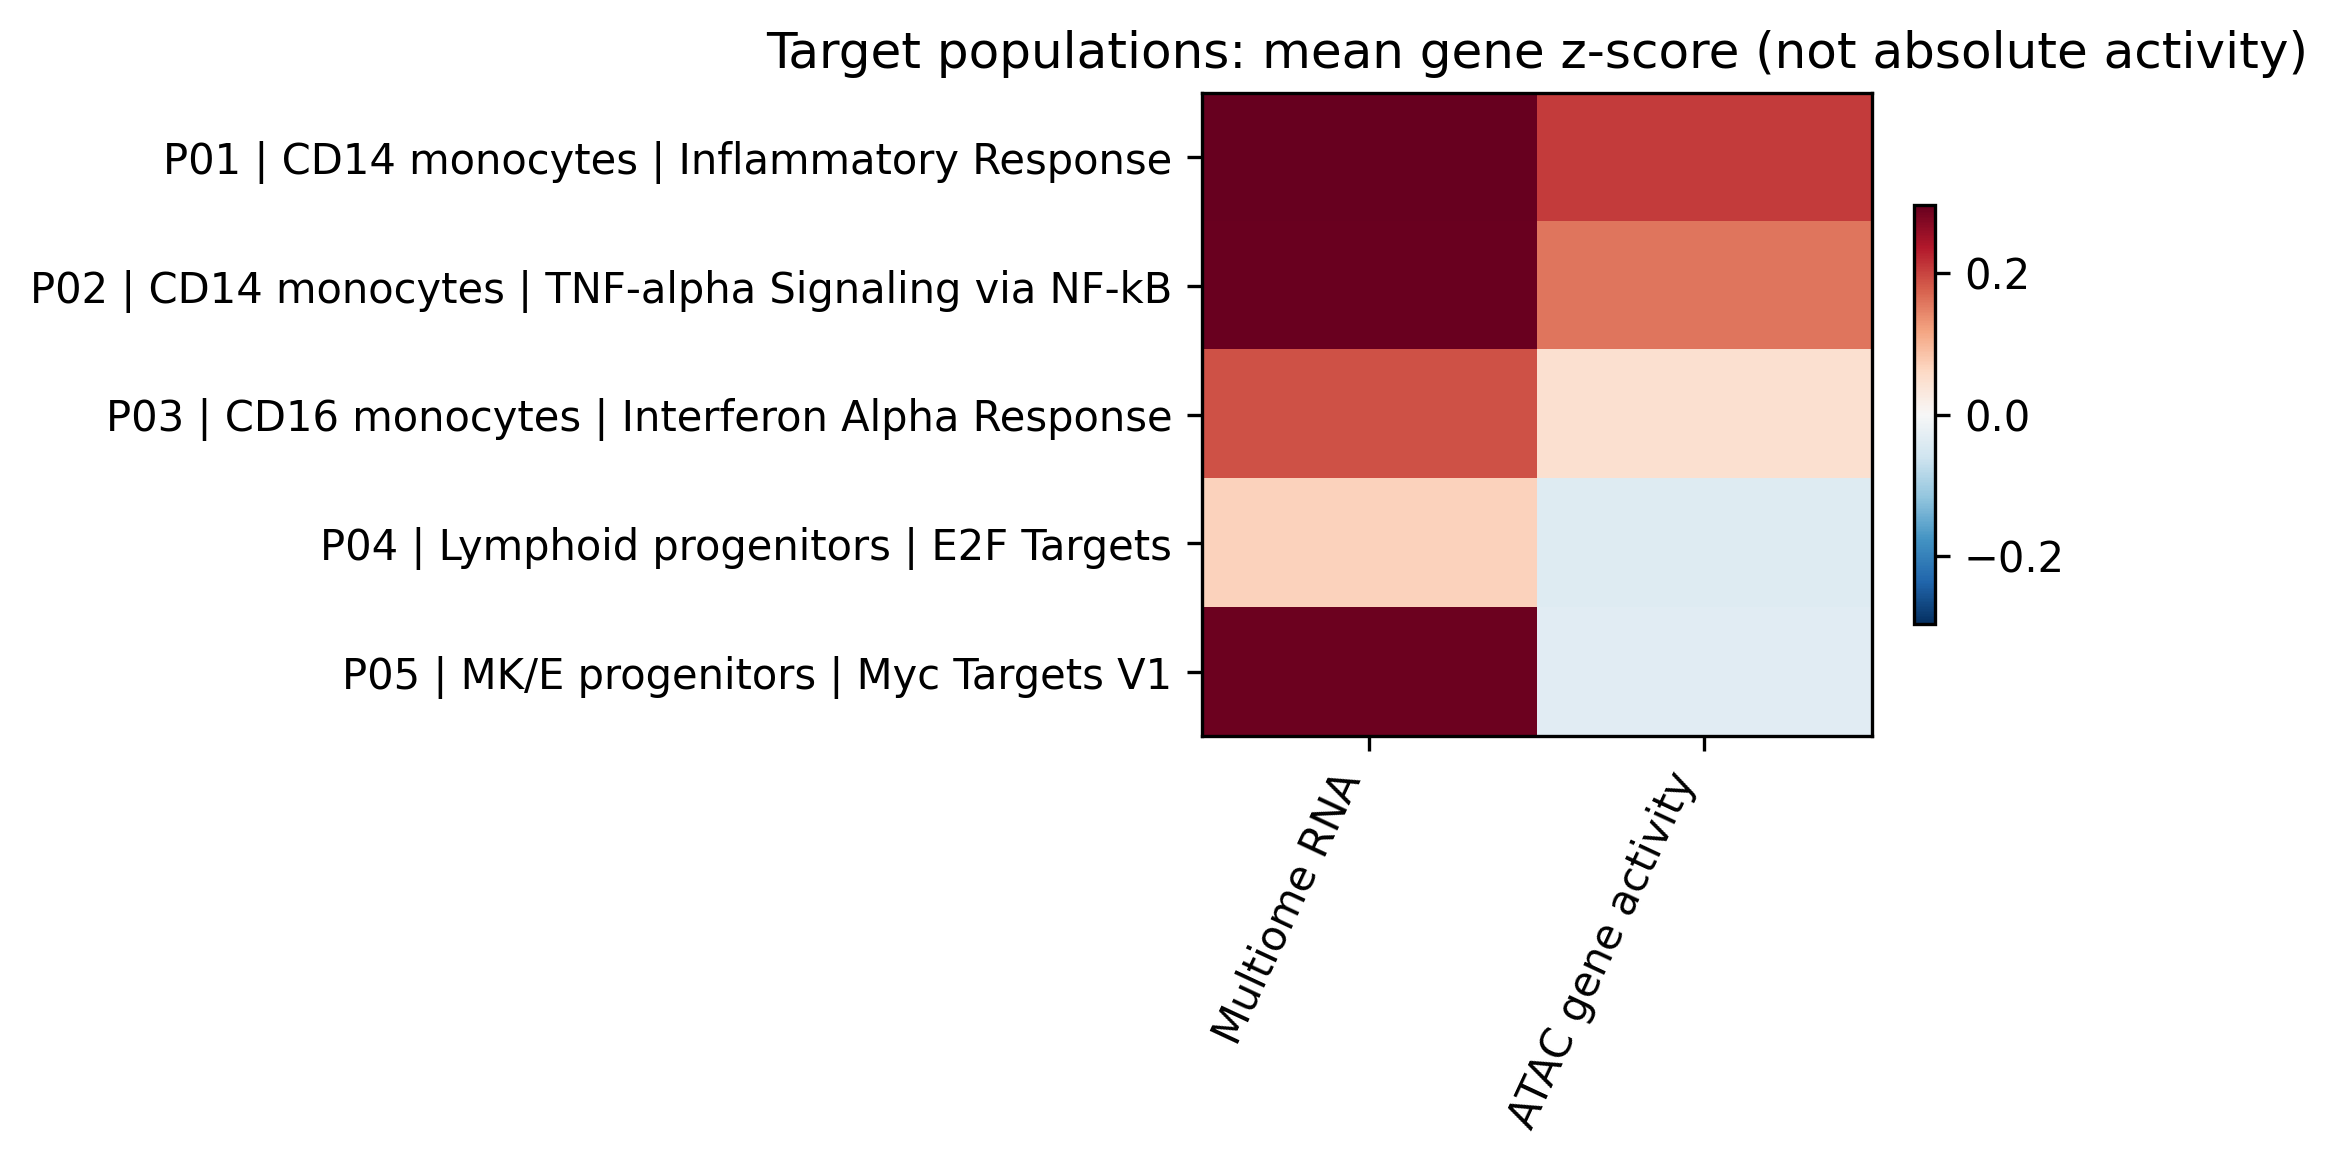

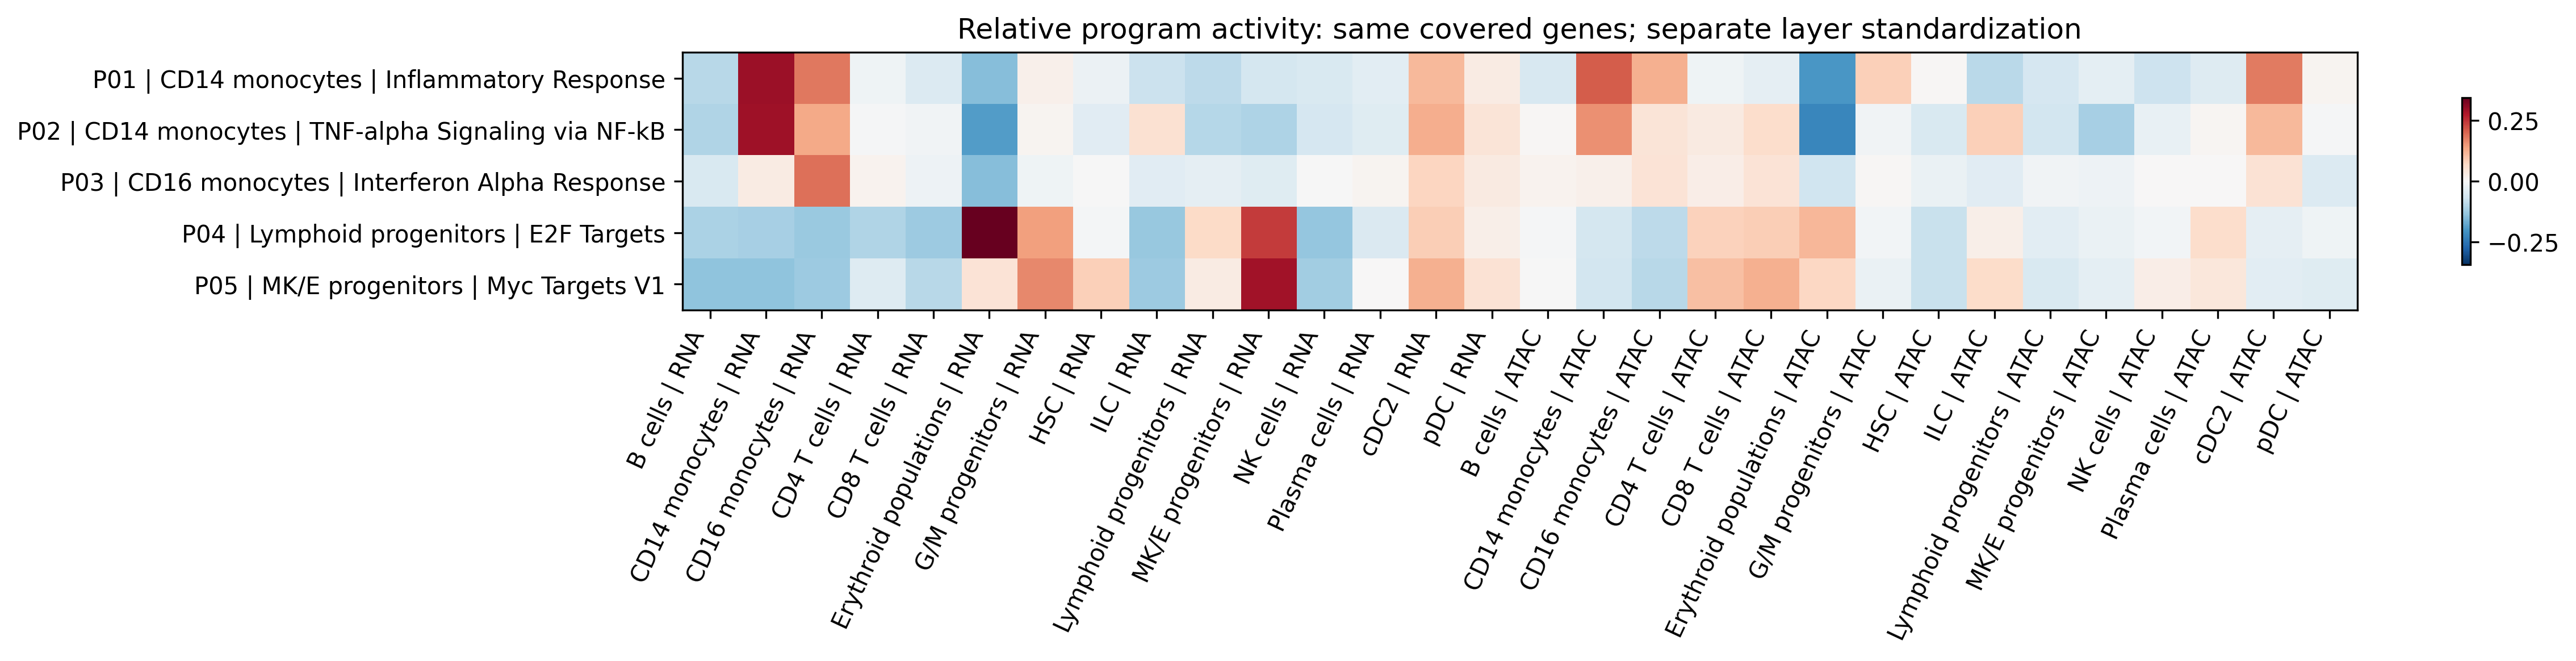

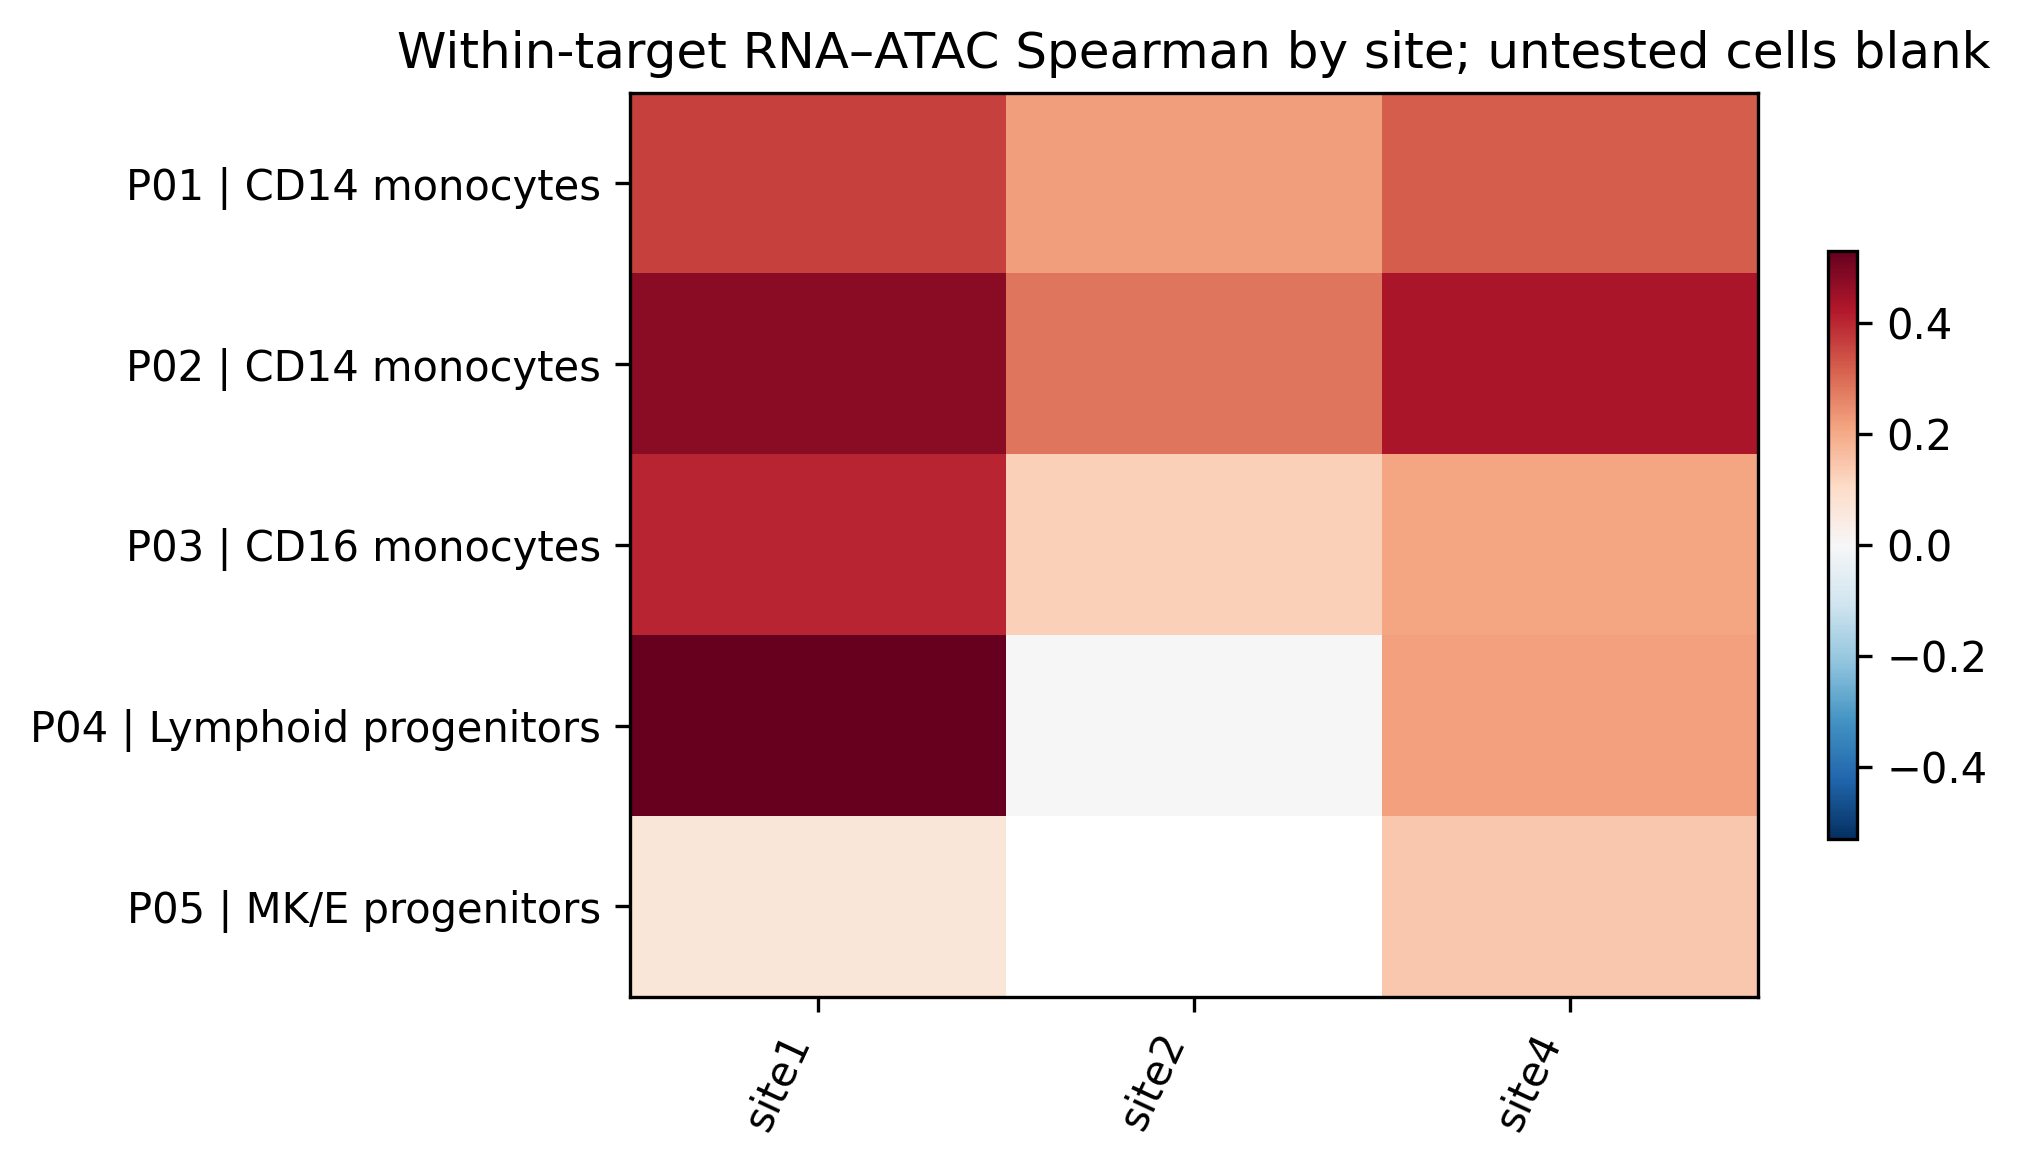

In [4]:
assoc = tables['associations']
primary = assoc[(assoc.scope == 'cell_type') & (assoc.group == assoc.cell_type)]
display(primary)
display(target_summary)
display(assoc[assoc.scope == 'target_by_site'])
for name in ['rna_atac_module_scatter.png', 'target_activity_heatmap.png',
             'population_activity_heatmap.png', 'site_association_heatmap.png']:
    if name in atac_manifest['figures']:
        display(Image(filename=str(DIRS['atac'] / 'figures' / name)))

## 7B — Shared RNA leading-edge genes
For each target population, report all covered, variable genes in the shared RNA
leading edge: RNA level, stored ATAC activity level, nonzero fractions and unadjusted/
depth-site-adjusted associations. ATAC nonzero fraction is a property of the processed
score, not a calibrated probability of promoter accessibility.

The figure shows up to three genes per program chosen by joint nonzero detection
coverage, not by strongest correlation. Statistics use all eligible cells; scatter
plots subsample solely for readability. Negative associations remain visible.

,program_id,cell_type,pathway,gene,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,rna_mean,atac_mean,rna_detection,atac_nonzero_fraction
0,P01,CD14 monocytes,Inflammatory Response,AHR,3243,True,0.053163,0.057747,0.067596,0.069864,1.191824,1.101936,0.529140,0.850755
1,P01,CD14 monocytes,Inflammatory Response,AQP9,3243,True,0.047300,0.027778,0.056751,-0.019966,0.229426,0.334085,0.119026,0.474252
2,P01,CD14 monocytes,Inflammatory Response,ATP2B1,3243,True,0.138456,0.149355,0.146428,0.161977,2.289768,0.739736,0.821770,0.736972
3,P01,CD14 monocytes,Inflammatory Response,C5AR1,3243,True,0.143357,0.123910,0.132510,0.137855,0.581410,0.480877,0.285230,0.585261
4,P01,CD14 monocytes,Inflammatory Response,CD14,3243,True,0.011936,-0.000367,0.010069,0.036560,0.467620,0.160850,0.258094,0.264878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,P05,MK/E progenitors,Myc Targets V1,VDAC1,298,True,-0.058805,-0.054320,-0.069015,-0.075801,0.290367,0.330476,0.197987,0.600671
337,P05,MK/E progenitors,Myc Targets V1,VDAC3,298,True,0.039843,0.013735,0.022206,0.032162,0.305656,0.210269,0.221477,0.466443
338,P05,MK/E progenitors,Myc Targets V1,XPO1,298,True,0.010299,0.021038,0.024555,0.038986,1.093453,0.505312,0.570470,0.714765
339,P05,MK/E progenitors,Myc Targets V1,XRCC6,298,True,-0.003917,0.001515,-0.040329,-0.018450,0.598768,0.326769,0.362416,0.604027


,program_id,cell_type,pathway,gene,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,rna_mean,atac_mean,rna_detection,atac_nonzero_fraction,joint_detection
0,P01,CD14 monocytes,Inflammatory Response,LYN,3243,True,0.014075,0.059805,0.064231,0.089225,2.349236,1.040327,0.855689,0.828862,0.709248
1,P05,MK/E progenitors,Myc Targets V1,HNRNPA2B1,298,True,-0.074041,-0.128906,-0.039770,-0.090965,1.926176,0.633114,0.832215,0.808725,0.673033
2,P01,CD14 monocytes,Inflammatory Response,NAMPT,3243,True,0.323958,0.344000,0.303193,0.313387,3.044874,0.852293,0.890842,0.751773,0.669711
3,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,NAMPT,3243,True,0.323958,0.344000,0.303193,0.313387,3.044874,0.852293,0.890842,0.751773,0.669711
4,P01,CD14 monocytes,Inflammatory Response,PTPRE,3243,True,0.014614,0.039045,0.027803,0.037139,1.842637,1.135920,0.758249,0.856306,0.649293
5,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,PTPRE,3243,True,0.014614,0.039045,0.027803,0.037139,1.842637,1.135920,0.758249,0.856306,0.649293
6,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,CD44,3243,True,0.074222,0.105144,0.117789,0.126631,2.177408,0.819470,0.799260,0.759790,0.607270
7,P05,MK/E progenitors,Myc Targets V1,SMARCC1,298,True,-0.046862,-0.036528,-0.039300,-0.039400,1.297070,0.788655,0.651007,0.842282,0.548331
8,P04,Lymphoid progenitors,E2F Targets,STAG1,452,True,0.021218,0.030734,0.015982,0.016689,1.614946,0.803347,0.659292,0.803097,0.529476
9,P05,MK/E progenitors,Myc Targets V1,HNRNPC,298,True,-0.075315,-0.109098,-0.103256,-0.120796,1.480297,0.496306,0.734899,0.691275,0.508018


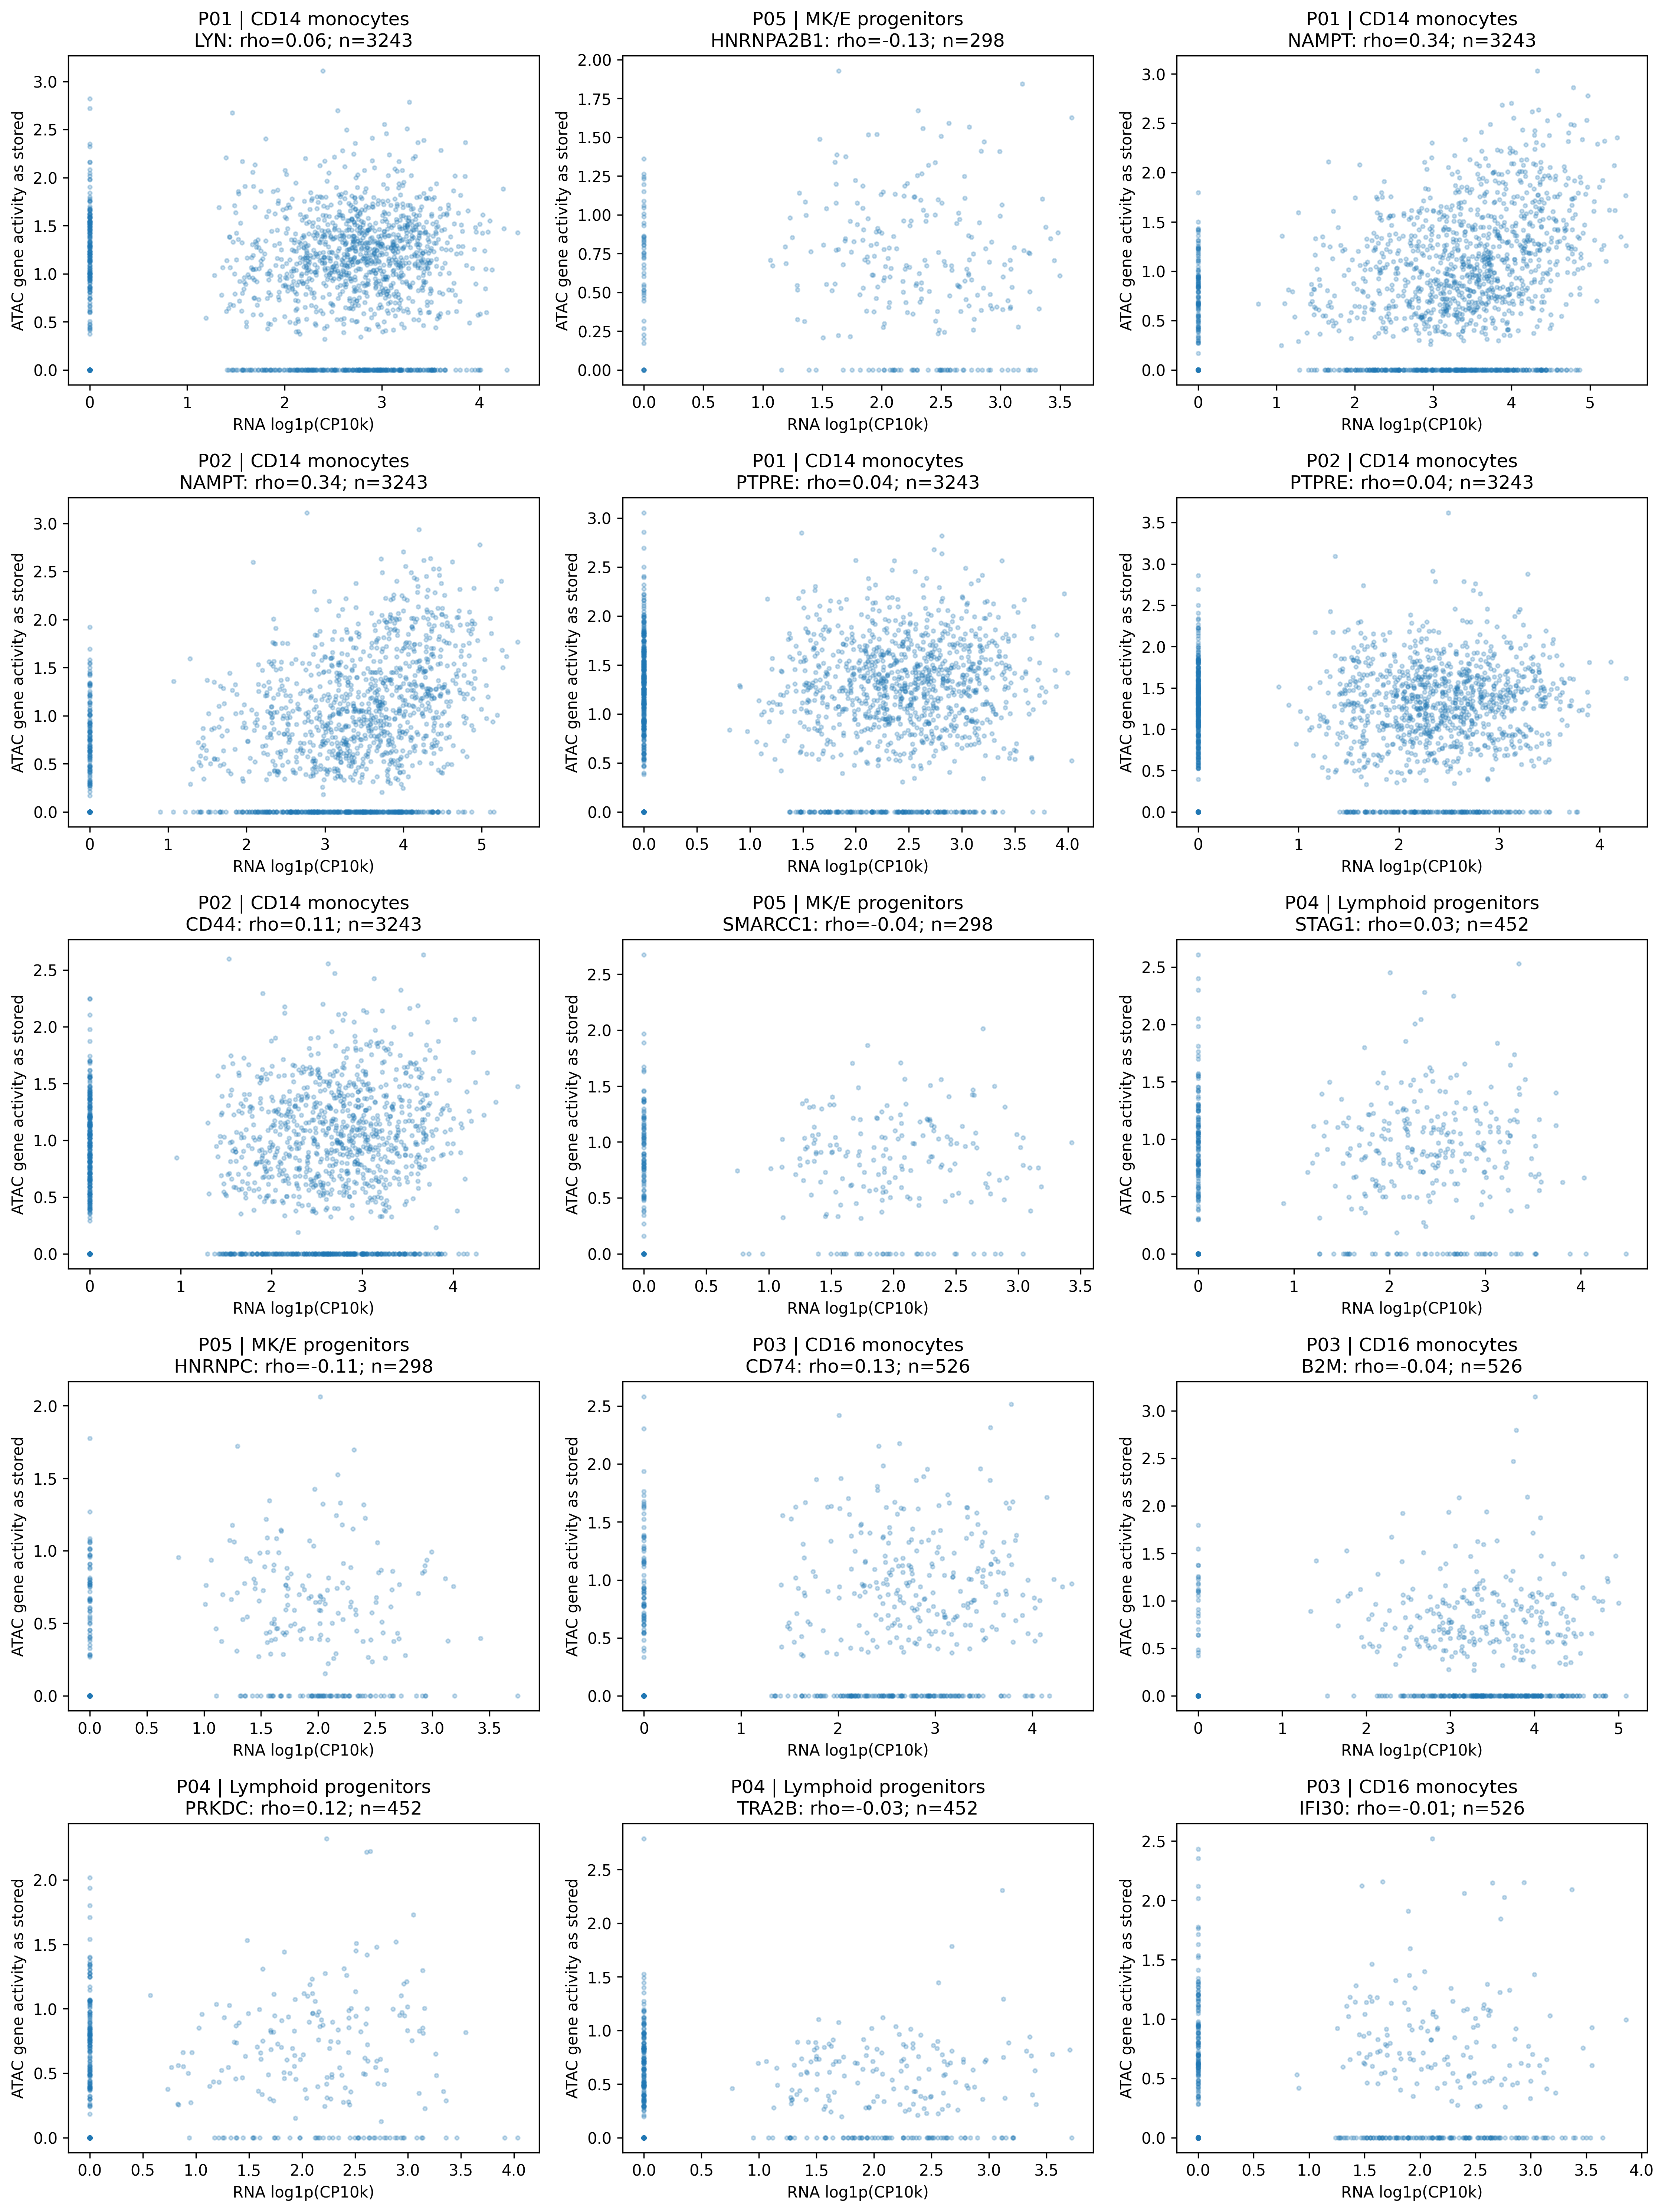

In [5]:
gene_results = tables['leading_edge_genes']
display(gene_results)
if 'leading_edge_gene_scatter.png' in atac_manifest['figures']:
    display(pd.read_csv(DIRS['atac'] / 'plotted_genes.csv'))
    display(Image(filename=str(DIRS['atac'] / 'figures/leading_edge_gene_scatter.png')))

## 7C — Relative population states and sensitivity
High means target population mean module score >= +0.5; low means <= -0.5.
Intermediate values remain **intermediate/mixed** rather than being forced into a
binary class. These are exploratory reference-relative cutoffs, not significance
thresholds or universal biological activation thresholds. The table also evaluates
0.25 and 0.75 to expose threshold dependence.

| Relative ATAC | Relative RNA | Cautious description |
|---|---|---|
| High | High | Elevated in both layers; assess within-type association separately |
| High | Low | Potentially permissive; not demonstrated temporal priming |
| Low | High | Candidate RNA/accessibility decoupling; consider score limitations |
| Low | Low | Relatively low in both; not proof of inactivity |

Accessibility preceding or permitting transcription cannot be established from these
cross-sectional data. Low gene activity is not proof of closed regulatory chromatin.

In [6]:
display(tables['state_threshold_sensitivity'])
if not primary.empty:
    display(primary[['cell_type', 'pathway', 'n_cells', 'spearman', 'adjusted_pearson',
                     'log1p_atac_spearman', 'leading_edge_spearman',
                     'rna_score_vs_rna_depth', 'atac_score_vs_atac_depth']])

,program_id,cell_type,pathway,threshold,n_cells,state
0,P01,CD14 monocytes,Inflammatory Response,0.25,3243,intermediate / mixed
1,P01,CD14 monocytes,Inflammatory Response,0.50,3243,intermediate / mixed
2,P01,CD14 monocytes,Inflammatory Response,0.75,3243,intermediate / mixed
3,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,0.25,3243,intermediate / mixed
4,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,0.50,3243,intermediate / mixed
5,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,0.75,3243,intermediate / mixed
6,P03,CD16 monocytes,Interferon Alpha Response,0.25,526,intermediate / mixed
7,P03,CD16 monocytes,Interferon Alpha Response,0.50,526,intermediate / mixed
8,P03,CD16 monocytes,Interferon Alpha Response,0.75,526,intermediate / mixed
9,P04,Lymphoid progenitors,E2F Targets,0.25,452,intermediate / mixed


,cell_type,pathway,n_cells,spearman,adjusted_pearson,log1p_atac_spearman,leading_edge_spearman,rna_score_vs_rna_depth,atac_score_vs_atac_depth
2,CD14 monocytes,Inflammatory Response,3243,0.198761,0.336784,0.141282,0.235861,0.592371,0.617482
21,CD14 monocytes,TNF-alpha Signaling via NF-kB,3243,0.435104,0.477397,0.369888,0.431256,0.555335,0.506412
41,CD16 monocytes,Interferon Alpha Response,526,0.076497,0.117519,0.075932,0.057551,0.671142,0.691215
67,Lymphoid progenitors,E2F Targets,452,0.340292,0.048267,0.357775,0.301139,0.708328,0.707799
87,MK/E progenitors,Myc Targets V1,298,0.376373,0.010419,0.357959,0.390532,0.773673,0.509250


## Main findings
No biological result is pre-filled. Use the quantitative outputs below to distinguish
coverage, relative population support, within-type covariation, depth/site sensitivity
and gene-level exceptions. Site-specific ATAC associations do not replace the still
outstanding site-specific **cross-capture RNA pathway** replication check from nb05.

In [7]:
print('Programs analyzed:', atac_manifest['n_programs_analyzed'], '/', atac_manifest['n_programs_requested'])
print('Paired Multiome cells in the reference:', atac_manifest['n_cells'])
if not target_summary.empty:
    display(target_summary[['cell_type', 'pathway', 'n_cells', 'rna_mean', 'atac_mean', 'state']])
if not primary.empty:
    display(primary[['cell_type', 'pathway', 'n_cells', 'tested', 'pearson', 'spearman', 'adjusted_pearson']])
print('Saved tables, PNG/PDF figures and provenance:', DIRS['atac'])
print('Review these outputs before protein follow-up. No causal or individual-level inference.')

Programs analyzed: 5 / 5
Paired Multiome cells in the reference: 18400


,cell_type,pathway,n_cells,rna_mean,atac_mean,state
1,CD14 monocytes,Inflammatory Response,3243,0.295613,0.207125,intermediate / mixed
16,CD14 monocytes,TNF-alpha Signaling via NF-kB,3243,0.291382,0.157299,intermediate / mixed
32,CD16 monocytes,Interferon Alpha Response,526,0.189353,0.046514,intermediate / mixed
54,Lymphoid progenitors,E2F Targets,452,0.067158,-0.037062,intermediate / mixed
70,MK/E progenitors,Myc Targets V1,298,0.290063,-0.032376,intermediate / mixed


,cell_type,pathway,n_cells,tested,pearson,spearman,adjusted_pearson
2,CD14 monocytes,Inflammatory Response,3243,True,0.195321,0.198761,0.336784
21,CD14 monocytes,TNF-alpha Signaling via NF-kB,3243,True,0.471505,0.435104,0.477397
41,CD16 monocytes,Interferon Alpha Response,526,True,0.067146,0.076497,0.117519
67,Lymphoid progenitors,E2F Targets,452,True,0.279346,0.340292,0.048267
87,MK/E progenitors,Myc Targets V1,298,True,0.331299,0.376373,0.010419


Saved tables, PNG/PDF figures and provenance: /content/drive/MyDrive/multiomics-relationship-modeling/results/single_donor/atac
Review these outputs before protein follow-up. No causal or individual-level inference.


## Limitations
- One donor; cells are not independent biological donor replicates.
- The reference uses retained harmonized populations, and broad labels can mix states.
- RNA and ATAC share Multiome cells, but CITE cells are separate captures.
- Gene activity is a processed approximation, not promoter-specific or peak-level
  regulatory evidence. The original activity transformation has not been established.
- Z-scores are relative to this donor/reference composition, not absolute activity.
- Full-program and leading-edge scores remain RNA-selected exploratory analyses.
- Site/depth adjustment can remove biological as well as technical variation; inspect
  both results. Cell cycle and other unmeasured covariates are not fully controlled.
- Within-site small groups may be untestable; missing coverage is not negative evidence.
- Balanced RNA direction is supported, but site-specific RNA pathway replication and
  the seven unavailable nb05 NES values remain separate outstanding checks.
- No protein evidence is available here. Later unmeasured ADTs must not be coded as low.
- Cross-sectional associations cannot establish ATAC → RNA causality or temporal priming.

## Reviewed analysis — donor 15078

All 18,400 Multiome reference cells were retained. The five programs had adequate
joint gene coverage, ranging from 63% to 98% of original pathway membership.

| Target population / program | Raw Pearson | Depth/site-adjusted Pearson | Interpretation |
|---|---:|---:|---|
| CD14 / inflammatory response | 0.195 | 0.337 | Positive RNA–ATAC association in all three observed sites |
| CD14 / TNF/NF-kB | 0.472 | 0.477 | Strongest adjusted association; positive across sites |
| CD16 / interferon-alpha | 0.067 | 0.118 | Weak overall association; site magnitudes vary |
| Lymphoid progenitors / E2F | 0.279 | 0.048 | Strong attenuation after adjustment; mixed site directions |
| MK/E progenitors / Myc V1 | 0.331 | 0.010 | Little overall adjusted association; one site untested |

These are within-target-population correlations in genuinely paired Multiome cells.
The CD14 programs have the clearest chromatin–RNA covariation. Attenuation for E2F
and Myc indicates sensitivity to the adjustment model, not proof of a technical
cause or biological decoupling. Adjustment can also remove biological variation.

All five population states remain intermediate/mixed at the evaluated 0.25, 0.5 and
0.75 cutoffs. Positive within-cell association does not imply high population mean
activity in both layers. These data establish neither temporal priming nor causality.
The next stage assesses measured surface proteins in separate, paired CITE cells.
